In [1]:
# LIBRERIE DI BASE E VISUALIZZAZIONE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# SCIKIT-LEARN: PRE-PROCESSING, MODELLI TRADIZIONALI E METRICHE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, precision_recall_curve, auc

### Carichiamo il dataset e visualizziamo le caratteristiche

Il dataset contiene informazioni su circa 45000 richieste di prestito a una banca, relativamente allo status del richiedente, all'ammontare e al tipo di prestito, e se il prestito è stato accettato o meno

In [2]:
data = pd.read_csv("./dataset/loan_data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

**Data.describe()** mi dà informazioni riguardanti alle statistiche sulle varie feature del dataset. Alcune feature hanno osservazioni probabilmente errate (età di 144 anni, o esperienza lavorativa di 125 anni)

In [4]:
data.describe() 

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
print(len(data))
data = data[(data['person_age'] <= 80) & (data['person_emp_exp'] <= 60)] #OCCUPIAMOCI DEI DATI "STRANI" COME ETA' DI 144 ANNI
print(len(data))

45000
44990


In [6]:
data.duplicated().sum() #Nessun duplicato

0

### Combino person age e person employment experience per ricavare una nuova feature, ovvero employment ratio

Employment ratio varierà da 0 a 1. Quanto più è alto, più quella persona avrà lavorato durante la propria vita

In [7]:
data['employment_ratio'] = data['person_emp_exp'] / data['person_age']

data = data.drop(['person_emp_exp'], axis=1)

In [8]:
data.describe()

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,employment_ratio
count,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,7.990883e+04,9583.297888,11.006510,0.139737,5.865259,632.578329,0.222272,0.167234
std,5.890563,6.332359e+04,6314.982527,2.979037,0.087208,3.874023,50.394327,0.415777,0.144848
min,20.000000,8.000000e+03,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,4.719575e+04,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.041667
50%,26.000000,6.704550e+04,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000,0.148148
75%,30.000000,9.577700e+04,12237.750000,12.990000,0.190000,8.000000,670.000000,0.000000,0.264706
max,78.000000,2.448661e+06,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000,0.763158


### Separo le feature (X) dalla variabile target (y)

In [9]:
X = data.drop('loan_status', axis=1)
y = data['loan_status']

In [10]:
# Dividiamo feature numeriche da feature categoriali
num_features = ['person_age','person_income', 'employment_ratio', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'] # Solo quelle continue/discrete vere
cat_features = ['person_gender', 'person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file'] # Quelle testuali da codificare


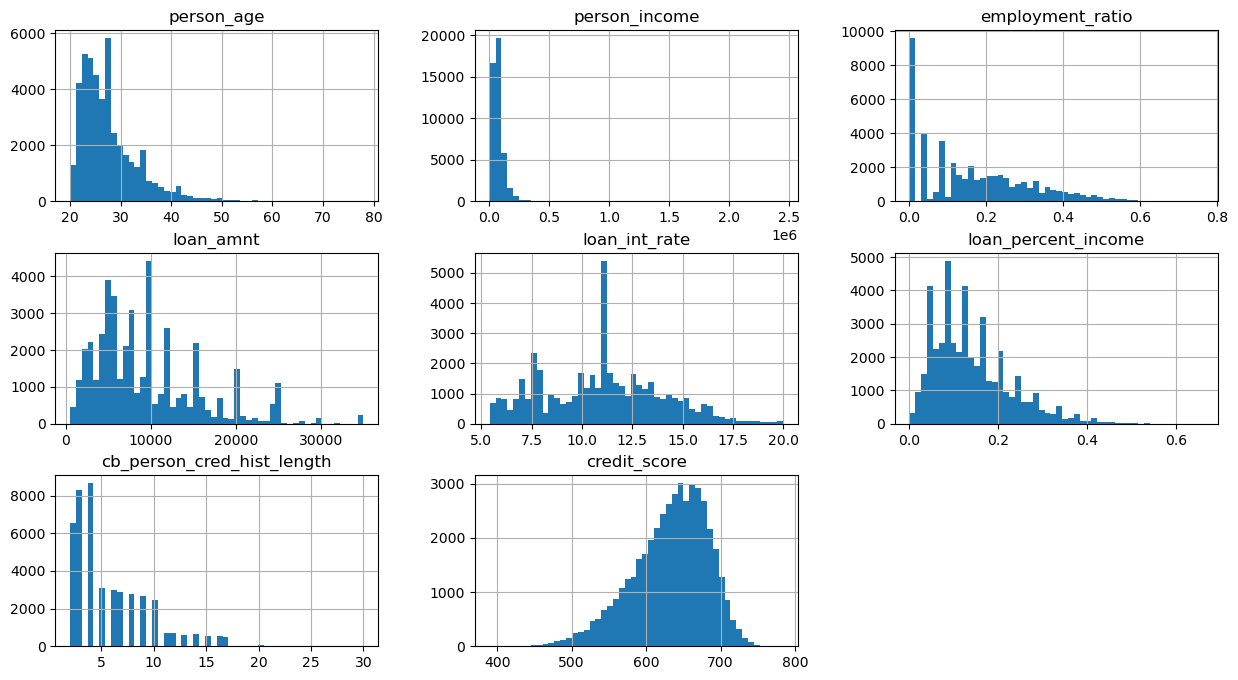

In [11]:

data[num_features].hist(bins=50, figsize=(15, 8))   
plt.show()

 Alcune feature hanno distribuzione piuttosto asimmetrica (molti outliers). Prima dello scaling, converrebbe fare una trasformazione logaritmica

In [12]:
data[num_features].skew()  

person_age                    1.864932
person_income                 9.694959
employment_ratio              0.709675
loan_amnt                     1.179709
loan_int_rate                 0.213891
loan_percent_income           1.034835
cb_person_cred_hist_length    1.625914
credit_score                 -0.616322
dtype: float64

In [13]:
#DIVIDO LE FEATURE NUMERICHE TRA QUELLE CHE DEVONO SUBIRE TRASFORMAZIONE LOGARITMICA E QUELLE CHE SONO GIA' OK

num_skewed = ['person_income', 'person_age', 'cb_person_cred_hist_length', 'loan_amnt', 'loan_percent_income']
num_normal = ['employment_ratio', 'loan_int_rate', 'credit_score']

### Ora preparo le operazioni di preprocessing. Utilizzo StandardScaler sulle feature numeriche e OneHotEncoder per le categoriali


In [14]:
#Definiamo il custom transformer

log_transformer = FunctionTransformer(np.log1p,  inverse_func=np.expm1,  feature_names_out='one-to-one')

# Pipeline per le asimmetriche (Log + Scaler)
skewed_pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())  #il risultato lo passo allo scaler
])

# ColumnTransformer Finale
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', skewed_pipeline, num_skewed),
        ('normal', StandardScaler(), num_normal),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

### Prima del preprocessing effettivo, effettuo lo split in train set (80%) e test set (20%)

**stratify=y** serve a garantire che la proporzione delle classi della variabile target rimanga la stessa sia nel set di addestramento (train set) sia nel set di test (test set).

**random_state** garantisce che la separazione delle righe sarà identica a ogni singola esecuzione del codice. (seme che viene usato per lo split)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(35992, 13)
(8998, 13)
(35992,)
(8998,)


Qui avviene effettivamente il preprocessing. Applico **fit_transform** sul train set. In questo modo prima fit() calcola i parametri necessari (ad esempio media e dev. standard per lo standard scaler), e poi usa quei parametri per la trasformazione con transform().

Sul test set, invece, uso solo transform in quanto i parametri per la standardizzazione vengono presi da X_train

In [16]:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Logistic Regression
Il primo modello che utilizzo è la Logistic Regression5t)

In [17]:

# La Logistic Regression è l'algoritmo lineare di base per la classificazione
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)


## Random Forest Classifier

Il secondo modello che testo è il RandomForestClassifier

In [18]:
# Il Random Forest è un potente modello ad albero, ottimo per catturare relazioni non lineari


rf_model = RandomForestClassifier(
    n_estimators=100,  
    max_depth=20,              # FRENO 1: Alberi non più profondi di 20 livelli
    min_samples_leaf=10,      # FRENO 2: Foglie finali con almeno 15 persone
    class_weight='balanced',  # (Sempre utile per il nostro target sbilanciato)
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [19]:
print("==============METRICHE LOGISTIC REGRESSION=========================\n")

print(classification_report(y_test, y_pred_lr, target_names=['Respinto','Accettato']))

print("==============METRICHE RANDOM FOREST=========================\n" )

print(classification_report(y_test, y_pred_rf, target_names=['Respinto','Accettato']))

==============METRICHE LOGISTIC REGRESSION=========================

              precision    recall  f1-score   support

    Respinto       0.98      0.84      0.90      6998
   Accettato       0.62      0.93      0.74      2000

    accuracy                           0.86      8998
   macro avg       0.80      0.88      0.82      8998
weighted avg       0.90      0.86      0.87      8998

==============METRICHE RANDOM FOREST=========================

              precision    recall  f1-score   support

    Respinto       0.97      0.91      0.94      6998
   Accettato       0.75      0.89      0.81      2000

    accuracy                           0.91      8998
   macro avg       0.86      0.90      0.88      8998
weighted avg       0.92      0.91      0.91      8998



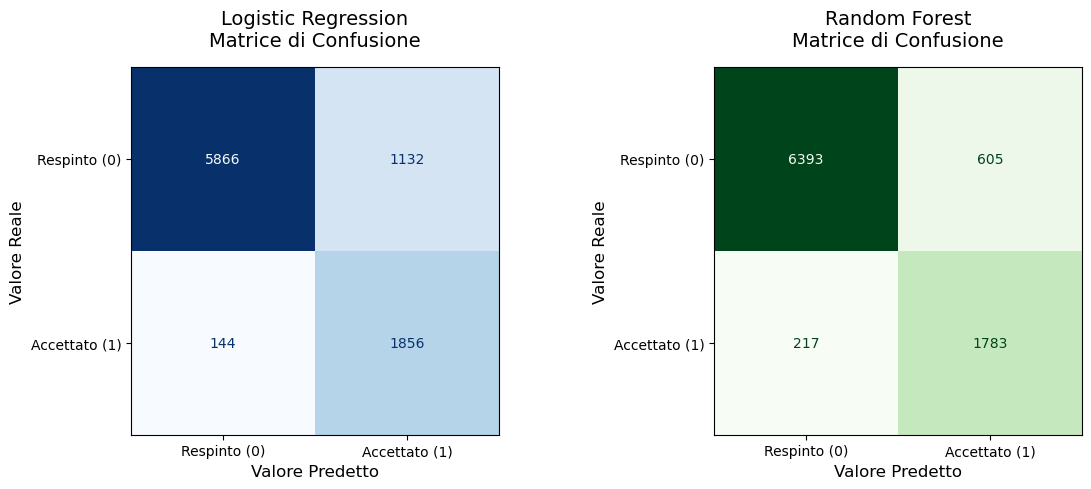

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Creazione dell'area di disegno: 1 riga, 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GRAFICO 1: LOGISTIC REGRESSION ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_lr, 
    display_labels=['Respinto (0)', 'Accettato (1)'], 
    cmap='Blues', 
    colorbar=False, 
    ax=axes[0]
)
axes[0].set_title('Logistic Regression\nMatrice di Confusione', fontsize=14, pad=15)
axes[0].set_xlabel('Valore Predetto', fontsize=12)
axes[0].set_ylabel('Valore Reale', fontsize=12)

# --- GRAFICO 2: RANDOM FOREST ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf, 
    display_labels=['Respinto (0)', 'Accettato (1)'], 
    cmap='Greens', 
    colorbar=False, 
    ax=axes[1]
)
axes[1].set_title('Random Forest\nMatrice di Confusione', fontsize=14, pad=15)
axes[1].set_xlabel('Valore Predetto', fontsize=12)
axes[1].set_ylabel('Valore Reale', fontsize=12)

# Ottimizza gli spazi e mostra il grafico
plt.tight_layout()
plt.show()

### Grafichiamo la precision/recall curve per visualizzare il trade-off precision/recall

In [21]:
# 1. Calcoliamo le probabilità previste per la Classe 1 (indice [:, 1])
y_probs_lr = log_reg.predict_proba(X_test)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

In [22]:
# 2. Calcoliamo Precision, Recall e Soglie per entrambi i modelli
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_probs_lr)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_probs_rf)

In [23]:
# 3. Calcoliamo l'Area Sotto la Curva (AUC-PR) per avere un voto riassuntivo
auc_lr = auc(recall_lr, precision_lr)
auc_rf = auc(recall_rf, precision_rf)

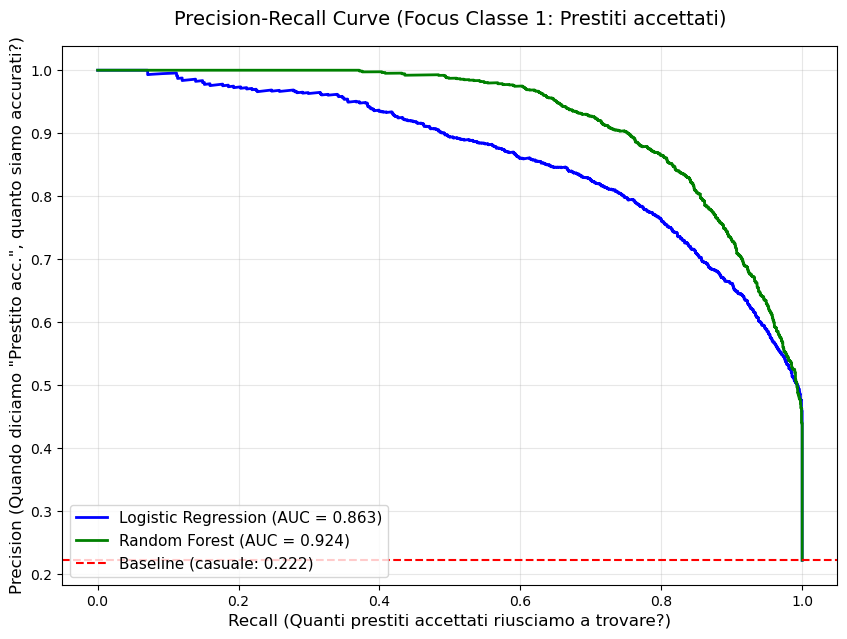

In [24]:
# 4. Creiamo il grafico
plt.figure(figsize=(10, 7))

# Plottiamo le due curve
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='blue', linewidth=2)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green', linewidth=2)

# Linea di baseline (rappresenta un classificatore casuale)
# Corrisponde alla proporzione di Classe 1 nel test set -> sum(y_test) sarebbe la somma di tutti gli 1 (accettato)
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (casuale: {baseline:.3f})')

# Personalizzazione del grafico
plt.title('Precision-Recall Curve (Focus Classe 1: Prestiti accettati)', fontsize=14, pad=15)
plt.xlabel('Recall (Quanti prestiti accettati riusciamo a trovare?)', fontsize=12)
plt.ylabel('Precision (Quando diciamo "Prestito acc.", quanto siamo accurati?)', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

#### Baseline 0.223 vuol dire che dicendo sempre "accettato" il fake classifier indovinerebbe il 22.2% delle volte

In [25]:

for s in [0.4, 0.5, 0.6]:
    preds_lr = (y_probs_lr > s)
    p = precision_score(y_test, preds_lr, pos_label=1)
    r = recall_score(y_test, preds_lr, pos_label=1)
    print(f"Soglia {s} -> Precision (Classe 1): {p:.2f} | Recall (Classe 1): {r:.2f}")

Soglia 0.4 -> Precision (Classe 1): 0.58 | Recall (Classe 1): 0.95
Soglia 0.5 -> Precision (Classe 1): 0.62 | Recall (Classe 1): 0.93
Soglia 0.6 -> Precision (Classe 1): 0.67 | Recall (Classe 1): 0.89


In [26]:
for s in [0.4, 0.5, 0.6]:
    preds_rf = (y_probs_rf > s)
    p = precision_score(y_test, preds_rf, pos_label=1)
    r = recall_score(y_test, preds_rf, pos_label=1)
    print(f"Soglia {s} -> Precision (Classe 1): {p:.2f} | Recall (Classe 1): {r:.2f}")

Soglia 0.4 -> Precision (Classe 1): 0.65 | Recall (Classe 1): 0.94
Soglia 0.5 -> Precision (Classe 1): 0.75 | Recall (Classe 1): 0.89
Soglia 0.6 -> Precision (Classe 1): 0.84 | Recall (Classe 1): 0.83
